# Dataset description
## cop - usd 

**Source**: Banco de la República

**Download**: [link](https://suameca.banrep.gov.co/estadisticas-economicas/informacionSerie/1/tasa_cambio_peso_colombiano_trm_dolar_usd)

# Code
## Imports

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
import matplotlib.ticker as mtick

## Load data

In [30]:
path = "data/trm.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [31]:
df_f = df.copy()

df_f["Fecha"] = pd.to_datetime(df_f["Fecha"])

df_f = df_f[df_f["Fecha"].dt.year >= 2010]

current_day = df_f["Fecha"].max()
current_value = df_f[df_f["Fecha"] == current_day]
all_dates = df_f["Fecha"].unique()

greater = df_f[df_f["trm"] >= current_value["trm"].item()].set_index("Fecha").reindex(all_dates)
smaller = df_f[df_f["trm"] <= current_value["trm"].item()].set_index("Fecha").reindex(all_dates)

## Plot

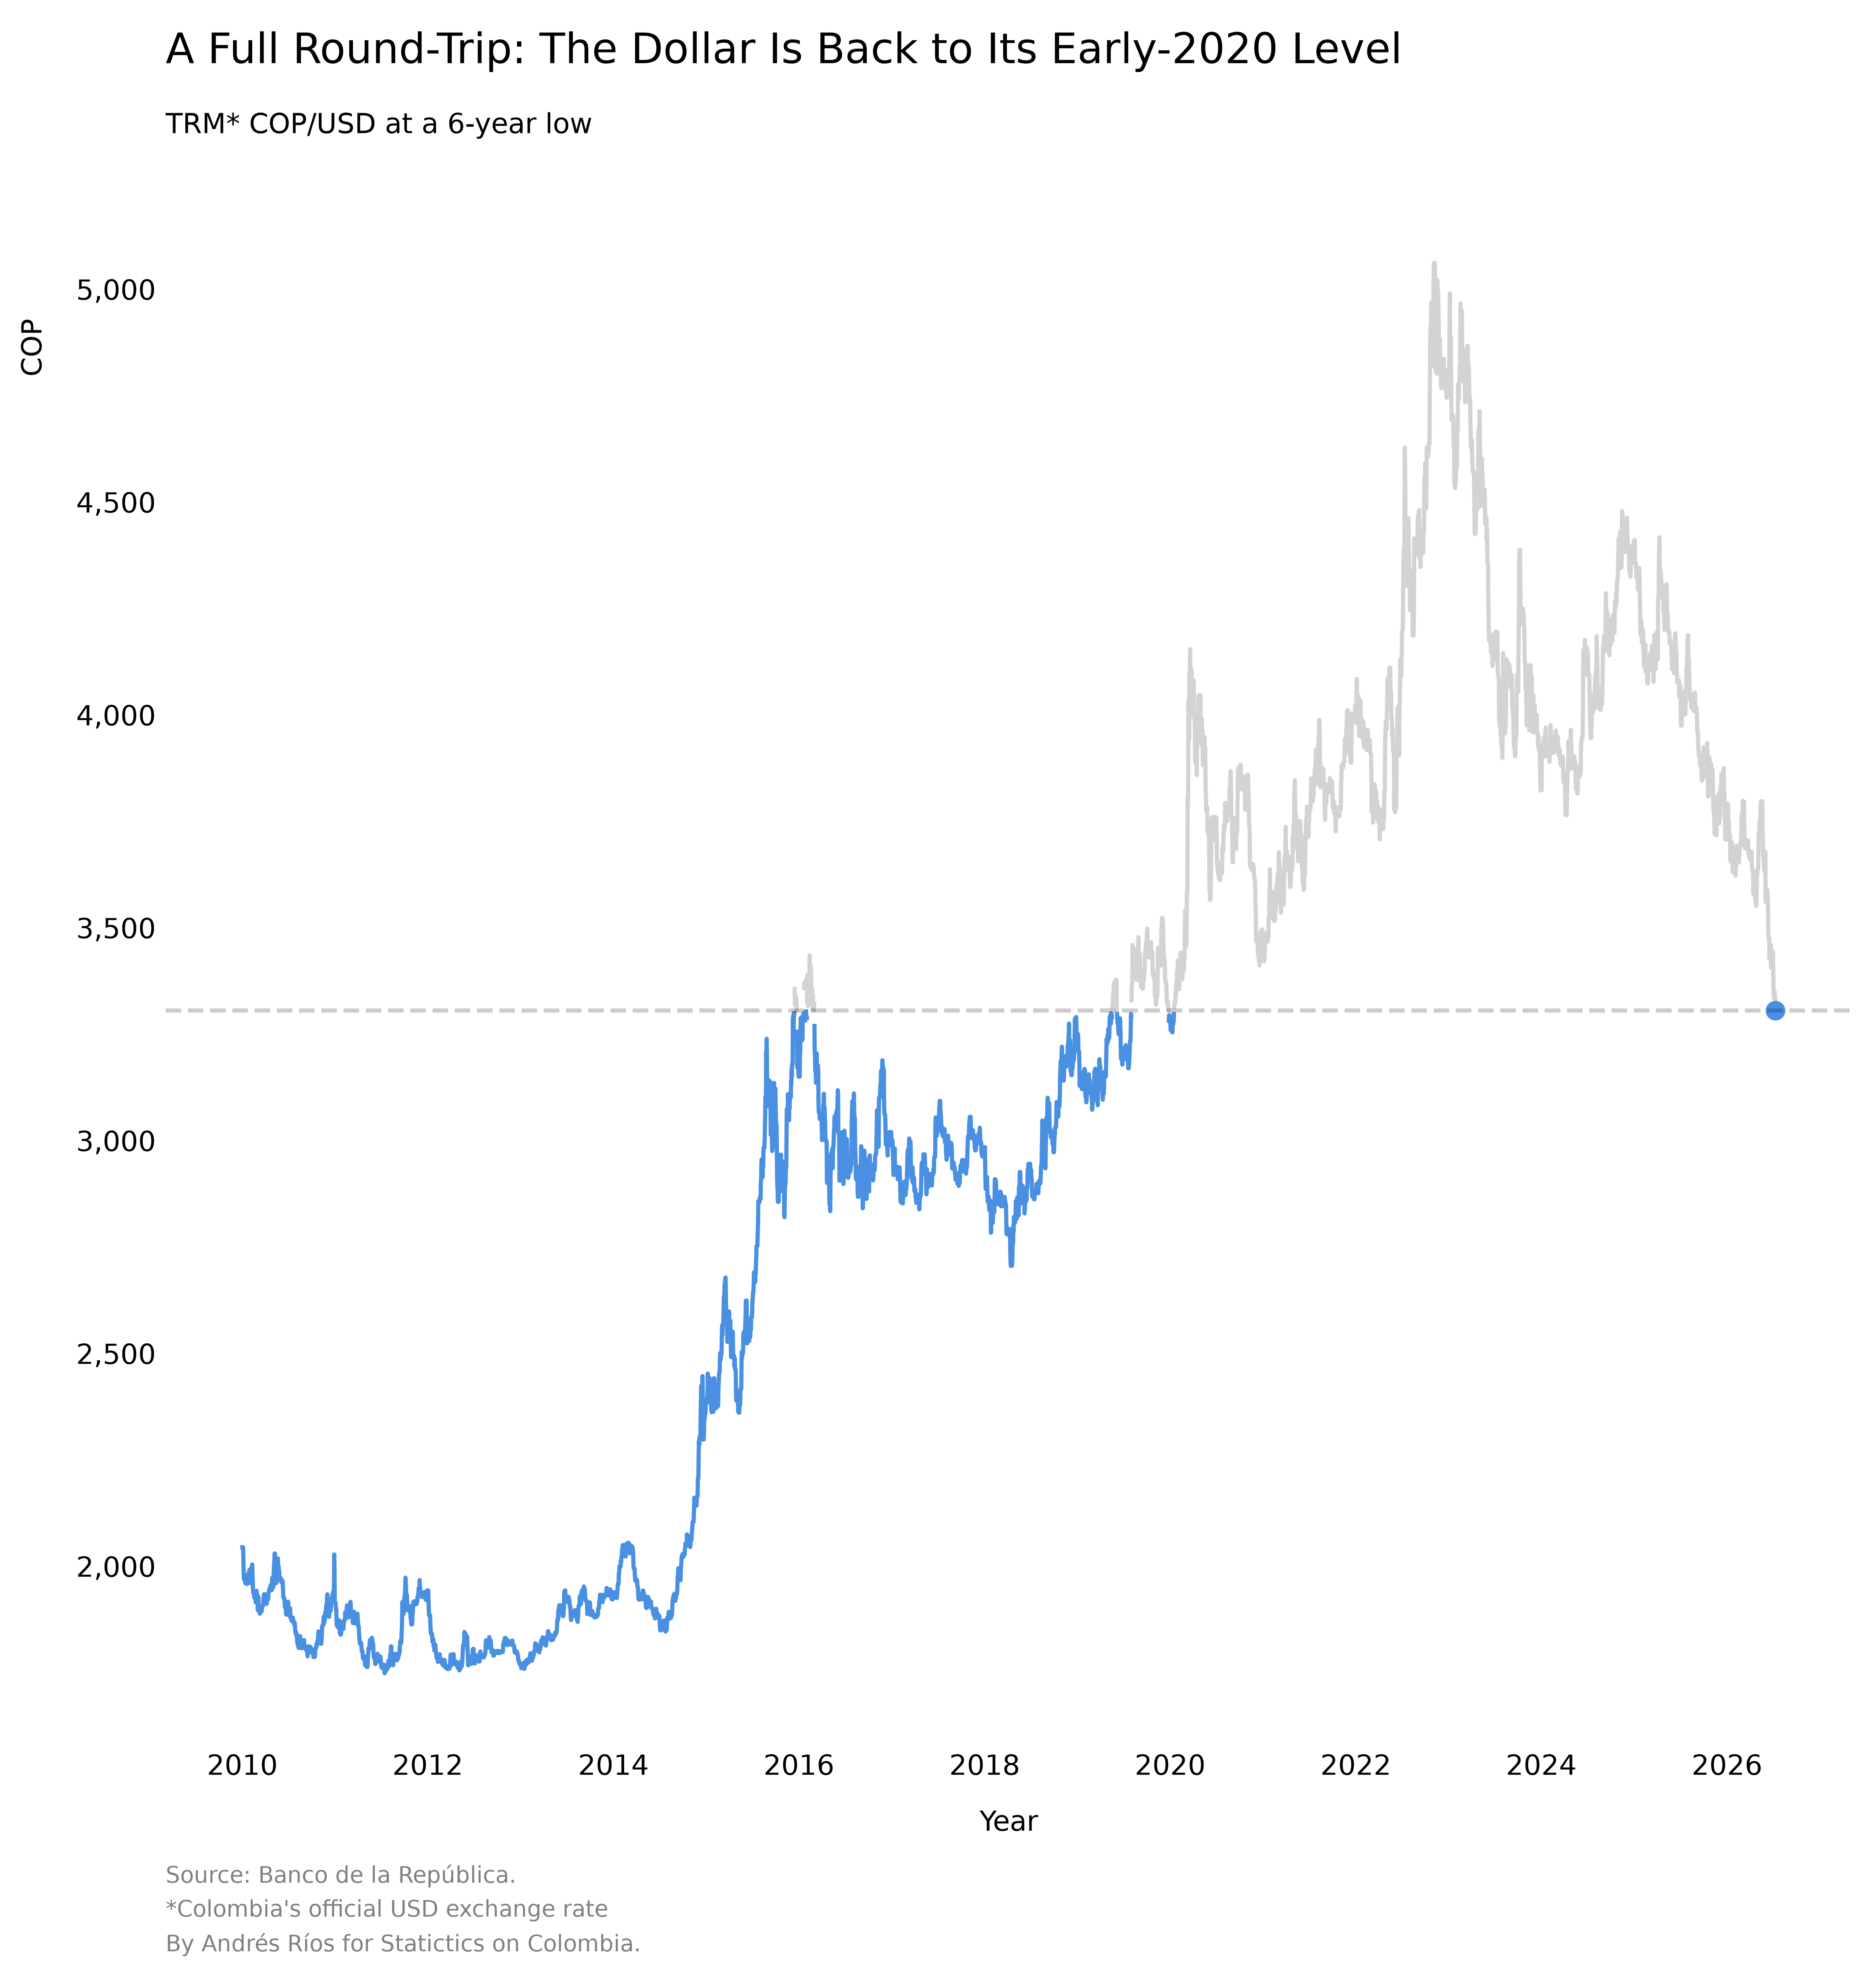

In [32]:
gray = "#D3D3D3"
blue = "#4a90e2"

plt.figure(figsize=(10.8, 10), dpi=500)

plt.plot(greater["trm"], color=gray)
plt.plot(smaller["trm"], color=blue)
plt.plot(greater.index.max(),current_value["trm"].item(), "o", color=blue)

plt.ylabel("COP", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.axhline(y=current_value["trm"].item(), color="black", alpha=0.2, linestyle="--")

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

fig_text(
    0.125, 0.96,
    s="A Full Round-Trip: The Dollar Is Back to Its Early-2020 Level",
    fontsize=15
)

fig_text(
    0.125, 0.92,
    s="TRM* COP/USD at a 6-year low",
    fontsize=10
)

fig_text(
    0.125, 0.05, 
    "Source: Banco de la República.\n"
    "*Colombia's official USD exchange rate\n"
    "By Andrés Ríos for Statictics on Colombia.", 
    fontsize=8, color="gray",
)

plt.show()